<a href="https://colab.research.google.com/github/CarisR/CarisR/blob/main/IoT_Sensor_Imputation_Benchmarking_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Dataset Imputation**

**Dataset**: IoT-Based Energy and Environmental Parameters in a Smart Building Infrastructure

**Source**: [github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure](https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure)

**Team**: Caris Rungkittikhun, Derrick O Nyagesuka, Lawrence K Lwanga \
**Institution**: Metropolitan State University \
**Instructor**: Professor Mousumi Munmun \
**Date last modified**: 2026/03/19

### **1. Main Imports**
This cell imports the essential libraries for data processing, machine learning, and advanced imputation. Key components include:

* **Core Utilities**: `os`, `glob`, and `warnings` for file handling and environment management.
* **Data Manipulation**: `pandas` and `numpy` for handling dataframes and numerical operations.
* **Visualization**: `matplotlib.pyplot` for generating plots.
* **Scikit-learn Suite**: Tools for data splitting (`train_test_split`), preprocessing (`StandardScaler`), and performance evaluation (`MSE`, `MAE`, `R2`).
* **Imputation Framework**:
    * **Standard**: `SimpleImputer`, `KNNImputer`, and the experimental `IterativeImputer` (using `DecisionTreeRegressor`).
    * **Advanced**: `SoftImpute` and `BiScaler` from the `fancyimpute` library, with a check to auto-install the package if missing.

In [65]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import time
import warnings

# Scikit-learn tools
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer # explicitly require this experimental feature
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Advanced Imputation
try:
    import fancyimpute
except ImportError:
    !pip install fancyimpute -q
    import fancyimpute

from fancyimpute import SoftImpute, BiScaler

warnings.filterwarnings('ignore')

### **2. Dataset Loading & Reshaping**
This section automates the retrieval, synchronization, and cleaning of the IoT sensor data.

* **Repository Setup**: Clones the source GitHub repository directly into the environment to access the raw CSV data.
* **Dynamic File Discovery**: Utilizes `glob` to recursively locate all CSV files across the project directory structure.
* **Data Transformation & Merging**:
    * Iterates through files to extract sensor values and identify device types and measurement units (e.g., `W`, `V`, `Temp`) via a mapping dictionary.
    * Converts timestamps to datetime objects and handles indexing to ensure chronological alignment.
    * Performs an **outer join** on all individual sensor streams to create a unified `merged` DataFrame.
* **Target Selection & Data Integrity**:
    * Sets `Fridge_W` as the primary target variable and removes entries where the target is missing.
    * **Leakage Prevention**: Identifies and drops columns related to the target device (other than the target itself) or irrelevant devices (e.g., `Desktop`) to ensure the model relies on independent environmental features.

In [66]:
# Clone and setup

repo_path = '/content/iot_data'
if not os.path.exists(repo_path):
    !git clone https://github.com/adel8641/Dataset-of-IoT-Based-Energy-and-Environmental-Parameters-in-a-Smart-Building-Infrastructure.git {repo_path}
else:
    print(f"Directory '{repo_path}' already exists. Skipping git clone.")

csv_files = glob.glob(f"{repo_path}/**/*.csv", recursive=True)

merged = None
measure_map = {'Watt W': 'W', 'Voltage V': 'V', 'Current A': 'A', 'Apperent power VA': 'VA',
               'Today': 'kWh_today', 'Total': 'kWh_total', 'Temperature': 'Temp',
               'Humidity': 'Humidity', 'Motion': 'State'}

for file in sorted(csv_files):
    temp = pd.read_csv(file)
    val_col = [c for c in temp.columns if c != 'time'][0]
    device = os.path.basename(file).replace('.csv', '').split(' Data ')[-1].strip().replace(' ', '_')
    col_name = f"{device}_{measure_map.get(os.path.basename(os.path.dirname(file)), 'Other')}"

    temp['time'] = pd.to_datetime(temp['time'], errors='coerce')
    temp = temp.dropna(subset=['time']).set_index('time')[[val_col]].rename(columns={val_col: col_name})
    merged = temp if merged is None else merged.join(temp, how='outer')

# Filter for Target and remove leakage
target = 'Fridge_W'
model_df = merged[merged[target].notna()].sort_index()
drop_cols = [c for c in model_df.columns if ('Fridge' in c and c != target) or 'Desktop' in c]
X = model_df.drop(columns=drop_cols)
y = model_df[target]

Directory '/content/iot_data' already exists. Skipping git clone.


### **3. Data Corrupting Function**
This section establishes a controlled environment for testing imputation performance by artificially introducing missingness into the dataset.

* **`corrupt_data` Utility**: A custom function designed to simulate sensor failures. It takes a DataFrame and a specified `rate` to randomly replace existing values with `np.nan`. A fixed random seed ensures reproducibility.
* **Data Splitting**: The features (`X`) and target (`y`) are partitioned into training and testing sets. This separation ensures that imputation models are developed on one subset and validated on another to prevent data leakage.
* **Simulated Missingness**:
    * **`X_test_corrupted`**: Created by applying a 20% corruption rate to the test set, serving as the primary benchmark for evaluating how well different strategies recover lost information.
    * **`X_train_corrupted`**: A similarly corrupted version of the training set, allowing for the development of models that are robust to noisy or incomplete input data.

In [67]:
def corrupt_data(df, rate, missing_type='MCAR', seed=42):
    np.random.seed(seed)
    corrupted = df.copy()

    # Pre-calculate percentile bounds for the whole dataframe
    low_p = (rate / 2) * 100
    high_p = 100 - ((rate / 2) * 100)

    if missing_type == 'MCAR':
        mask = np.random.rand(*df.shape) < rate
        corrupted[mask] = np.nan

    elif missing_type == 'MAR':
        # Select 3 columns to drive missingness in others
        v_cols = df.columns.tolist()
        v_observed = np.random.choice(v_cols, size=min(3, len(v_cols)), replace=False)
        v_missing = [c for c in v_cols if c not in v_observed]

        # Vectorized check for tails in observed columns
        obs_data = df[v_observed].values
        low_vals = np.nanpercentile(obs_data, low_p, axis=0)
        high_vals = np.nanpercentile(obs_data, high_p, axis=0)

        # Row is "in the tail" if any observed column is outside bounds
        row_mask = np.any((obs_data < low_vals) | (obs_data > high_vals), axis=1)
        corrupted.loc[row_mask, v_missing] = np.nan

    elif missing_type == 'MNAR':
        # Vectorized: Calculate all column bounds at once
        vals = df.values
        low_vals = np.nanpercentile(vals, low_p, axis=0)
        high_vals = np.nanpercentile(vals, high_p, axis=0)

        # Apply mask: value is missing if it's in its own tail
        mask = (vals < low_vals) | (vals > high_vals)
        corrupted.iloc[:] = np.where(mask, np.nan, vals)

    return corrupted

# Initial Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a corrupted test set for individual strategy demonstration (20% missingness)
X_test_corrupted = corrupt_data(X_test, 0.20)

# Create a corrupted training set for individual strategy demonstration (20% missingness)
X_train_corrupted = corrupt_data(X_train, 0.20)

### **4. Various Imputation Strategies**

#### **4a-c. Baseline Strategy (Statistical Trio)**
This section implements three fundamental statistical imputation methods to serve as a performance baseline. These methods replace missing entries using simple aggregate values calculated from the observed data.

* **Statistical Methods Dictionary**: Initializes a dictionary, `stat_methods`, containing three `SimpleImputer` configurations:
    * **Mean**: Replaces missing values with the average of the column.
    * **Median**: Replaces missing values with the middle value of the column (robust to outliers).
    * **Most Frequent**: Replaces missing values with the mode (useful for categorical or skewed numerical data).
* **Fitting and Transformation**:
    * The imputers are **fit** on the `X_train_corrupted` dataset to learn the specific statistics (mean, median, or mode) from the available training information.
    * Each imputer then **transforms** the `X_test_corrupted` DataFrame, systematically filling in `NaN` values.
* **Result Storage**: The resulting imputed DataFrames are organized into the `X_test_stats` dictionary, allowing for streamlined comparison against more complex algorithms in the evaluation phase.

In [68]:
# 4. Baseline (Statistical)
# Sub-strategies for Statistical Baselines
stat_methods = {
    'Mean': SimpleImputer(strategy='mean'),
    'Median': SimpleImputer(strategy='median'),
    'Mode': SimpleImputer(strategy='most_frequent') # Updated to 'Mode' for clarity
}

X_demo_stats = {}
for name, imputer in stat_methods.items():
    # FIT on corrupted TRAIN, TRANSFORM corrupted TEST
    imputer.fit(X_train_corrupted)
    X_demo_stats[name] = pd.DataFrame(
        imputer.transform(X_test_corrupted),
        columns=X.columns, index=X_test.index
    )
    print(f"Demonstration: Statistical ({name}) Strategy Ready.")

Demonstration: Statistical (Mean) Strategy Ready.
Demonstration: Statistical (Median) Strategy Ready.
Demonstration: Statistical (Mode) Strategy Ready.


#### **4d. Temporal Strategy (Time-Series)**
This section applies specialized time-series imputation techniques that leverage the chronological order of observations to fill gaps, specifically utilizing **LOCF** and **NOCB** logic.

* **LOCF (Last Observation Carried Forward)**: Implemented via `ffill` (forward fill). This method propagates the last known valid sensor reading into subsequent missing slots, assuming the state remains constant until a new measurement is recorded.
* **NOCB (Next Observation Carried Backward)**: Implemented via `bfill` (backward fill). This serves as a secondary pass to handle missing values at the very beginning of the dataset where no "last observation" exists, using the first available future value instead.
* **Residual Cleanup**: As a final safeguard, any remaining `NaN` values—which may occur if a specific sensor column is entirely empty—are filled with **0** to ensure the dataset is computationally ready for model prediction.

In [69]:
# LOCF (Last Observation Carried Forward) + NOCB (Next Observation Carried Backward)
X_demo_temp = X_test_corrupted.ffill().bfill().fillna(0)
print("Demonstration: Temporal Strategy Ready.")

Demonstration: Temporal Strategy Ready.


#### **4e. Relational Strategy (K-Nearest Neighbors)**
This section utilizes the `KNNImputer` to fill missing entries by identifying similar data points within the multidimensional feature space.

* **`KNNImputer` Configuration**: The imputer is initialized with `n_neighbors=5`. For every missing value, the algorithm identifies the 5 most similar samples (neighbors) based on Euclidean distance across all available features.
* **Mean-Based Attribution**: The missing value is then estimated as the mean of the corresponding feature values from those 5 identified neighbors, effectively leveraging local data correlations.
* **Fit and Transform**:
    * The `fit_transform` method is applied directly to `X_test_corrupted`. Unlike some models, `KNNImputer` is designed to handle existing `NaN` values during the distance calculation and fitting process.
    * The resulting NumPy array is wrapped back into a `pandas.DataFrame`, preserving the original column names and time-series indices for downstream analysis.

In [70]:
knn_imp = KNNImputer(n_neighbors=5)
X_demo_knn = pd.DataFrame(
    knn_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Relational Strategy Ready.")

Demonstration: Relational Strategy Ready.


#### **4f. Predictive Strategy (Iterative / MICE)**
This section implements a sophisticated multivariate approach known as **MICE (Multiple Imputation by Chained Equations)**, which treats each feature with missing data as a target in a regression problem.

* **`IterativeImputer` Configuration**: The model is initialized with a `random_state=42` for consistent results and a `max_iter=10` limit. This specifies how many cycles the algorithm will run to refine its predictions.
* **The MICE Mechanism**:
    * **Feature-as-Target**: For every column containing missing values, the imputer models it as a function of all other available features.
    * **Chained Equations**: It iteratively cycles through all features, updating estimates based on the most recent values of the others. This "chained" process allows the model to capture complex inter-dependencies between different sensor readings.
* **Execution**: The `fit_transform` method is applied to `X_test_corrupted`. Once the iterations converge or reach the maximum limit, the resulting data is reconstructed into a `pandas.DataFrame` to maintain the original temporal index and feature labels.

In [71]:
iter_imp = IterativeImputer(random_state=42, max_iter=10)
X_test_pred = pd.DataFrame(
    iter_imp.fit_transform(X_test_corrupted),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Predictive Strategy Ready.")

Demonstration: Predictive Strategy Ready.


#### **4g. Matrix Strategy (Sparsity)**
This section employs advanced matrix factorization techniques from the `fancyimpute` library, specifically **SoftImpute**, which is highly effective for high-dimensional data with sparse (missing) values.

* **`BiScaler` Normalization**: Matrix factorization algorithms are sensitive to variable scales. `BiScaler` is utilized to perform **doubly-standardized scaling**, ensuring the data has zero mean and unit variance across both rows and columns before the imputation process begins.
* **`SoftImpute` Mechanism**:
    * **Low-Rank Approximation**: This algorithm uses an iterative soft-thresholding approach based on **Singular Value Decomposition (SVD)**.
    * **Data Recovery**: It fills missing entries by finding a low-rank matrix that best fits the observed sensor data, effectively capturing the global structure of the dataset.
* **Workflow & Inverse Transformation**:
    1.  **Fit & Transform**: `X_test_corrupted` is converted to a NumPy array and normalized via `scaler.fit_transform()`.
    2.  **Factorization**: The scaled matrix is processed by `soft_imp.fit_transform()` to resolve missing values.
    3.  **Rescaling**: The results are passed through `scaler.inverse_transform()` to return the data to its original physical units (e.g., Watts, Volts).
    4.  **Reconstruction**: The final array is wrapped back into a `pandas.DataFrame` to maintain the original temporal context.

In [72]:
scaler = BiScaler(verbose=False)
soft_imp = SoftImpute(verbose=False)

# Matrix math requires scaling first
X_test_scaled = scaler.fit_transform(X_test_corrupted.values)
X_test_matrix_raw = soft_imp.fit_transform(X_test_scaled)
X_test_matrix = pd.DataFrame(
    scaler.inverse_transform(X_test_matrix_raw),
    columns=X.columns,
    index=X_test.index
)
print("Demonstration: Matrix Strategy Ready.")

Demonstration: Matrix Strategy Ready.


### **5. The Benchmarking Engine**
This core evaluation section systematically tests the resilience of each imputation strategy across varying levels of sensor failure, simulating real-world data degradation.

* **`evaluate_metrics` Function**: A custom helper that calculates three key performance indicators: **Mean Absolute Error (MAE)**, **Root Mean Squared Error (RMSE)**, and **R-squared ($R^2$)**. It uses the trained model to predict outcomes from the imputed datasets and compares them against the ground truth (`y_test`).
* **Variable Missingness Levels**: The engine defines an array of `rates` (10%, 20%, 30%, 40%, and 50%) to evaluate how each strategy scales as data sparsity increases.
* **The Benchmark Judge**: A `DecisionTreeRegressor` is pre-trained on the "clean" training set. This model acts as the static judge, determining how "repairable" the data is under different imputation methods.
* **Iterative Simulation Loop**: For every failure rate, the following workflow is executed:
    * **Simulated Corruption**: Both training and test sets are artificially corrupted to mimic a scenario where the analyst has never seen "perfect" historical data.
    * **Execution & Timing**: Each strategy (Statistical, Temporal, KNN, MICE, and SoftImpute) is applied. The system tracks the execution time for each to assess the trade-off between accuracy and computational cost.
    * **Strategy Implementation**:
        * **Statistical**: Learners are `fit` on corrupted training data and `transform` the test data.
        * **Advanced (KNN/MICE/Matrix)**: These leverage the relationships within the corrupted test set itself via `fit_transform`.
* **Result Consolidation**:
    * **Metrics Tracking**: All performance data is stored in a master list, `all_results`.
    * **Visual Sampling**: For the 20% failure rate, the engine captures raw prediction samples for later side-by-side time-series visualization.
    * **Final Reporting**: The results are converted into `results_df`, a structured DataFrame optimized for comparative analysis and ranking.

In [73]:
import time
from joblib import Parallel, delayed
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from fancyimpute import SoftImpute, BiScaler

def evaluate_metrics(imputed_data, true_y, model):
    """Evaluates a given imputed dataset against the true_y."""
    # Ensure no NaNs remain before prediction
    final_data = imputed_data.fillna(0)
    preds = model.predict(final_data)
    mae = mean_absolute_error(true_y, preds)
    rmse = np.sqrt(mean_squared_error(true_y, preds))
    r2 = r2_score(true_y, preds)
    return mae, rmse, r2

def run_single_simulation(m_type, rate, X_train, X_test, y_train, y_test, model):
    """Worker function for parallel execution."""
    rate_label = f"{int(rate*100)}%"
    results = []
    local_samples = {}

    # 1. Corrupt
    X_tr_corr = corrupt_data(X_train, rate, missing_type=m_type)
    X_te_corr = corrupt_data(X_test, rate, missing_type=m_type)

    strategies = {}
    times = {}

    # --- Strategy Definitions (Optimization: Inline fit_transform where possible) ---
    # Statistical
    s = time.time(); strategies["Stat (Mean)"] = pd.DataFrame(SimpleImputer(strategy='mean').fit_transform(X_te_corr), columns=X_test.columns); times["Stat (Mean)"] = time.time()-s
    s = time.time(); strategies["Stat (Median)"] = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X_te_corr), columns=X_test.columns); times["Stat (Median)"] = time.time()-s
    s = time.time(); strategies["Stat (Mode)"] = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X_te_corr), columns=X_test.columns); times["Stat (Median)"] = time.time()-s

    # Temporal
    s = time.time(); strategies["Temporal (Ffill)"] = X_te_corr.ffill().bfill().fillna(0); times["Temporal (Ffill)"] = time.time()-s

    # Relational (KNN)
    s = time.time(); strategies["Relational (KNN)"] = pd.DataFrame(KNNImputer(n_neighbors=5).fit_transform(X_te_corr), columns=X_test.columns); times["Relational (KNN)"] = time.time()-s

    # Predictive (MICE)
    s = time.time(); strategies["Predictive (MICE)"] = pd.DataFrame(IterativeImputer(max_iter=10, random_state=42).fit_transform(X_te_corr), columns=X_test.columns); times["Predictive (MICE)"] = time.time()-s

    # Matrix (SoftImpute)
    s = time.time(); scaler = BiScaler(verbose=False); soft = SoftImpute(verbose=False)
    soft_out = scaler.inverse_transform(soft.fit_transform(scaler.fit_transform(X_te_corr.values)))
    strategies["Matrix (SoftImpute)"] = pd.DataFrame(soft_out, columns=X_test.columns); times["Matrix (SoftImpute)"] = time.time()-s

    # Benchmarks
    strategies["Clean (Perfect Data)"] = X_test
    strategies["Corrupted (Unrepaired)"] = X_te_corr.fillna(0)

    # 2. Evaluate
    for name, data in strategies.items():
        mae, rmse, r2 = evaluate_metrics(data, y_test, model)

        # Sample storage logic (Modified for parallel return)
        if rate == 0.20 and m_type == 'MCAR':
            local_samples[name] = model.predict(data.fillna(0))

        results.append({
            "Type": m_type, "Rate": rate_label, "Strategy": name,
            "MAE": mae, "RMSE": rmse, "R²": r2, "Time (s)": times.get(name, 0)
        })

    return results, local_samples

# --- EXECUTION ---
# Setup tasks
missing_types = ['MCAR', 'MAR', 'MNAR']
rates = [0.10, 0.20, 0.30, 0.40, 0.50]
tasks = [(t, r) for t in missing_types for r in rates]

print(f"Starting parallel engine on {len(tasks)} simulation scenarios...")

# Run Parallel Loop
# n_jobs=-1 uses all available CPU cores
parallel_output = Parallel(n_jobs=-1)(
    delayed(run_single_simulation)(t, r, X_train, X_test, y_train, y_test, model)
    for t, r in tasks
)

# --- RECONSTRUCT RESULTS ---
all_results = []
prediction_samples = {}

for res_list, samp_dict in parallel_output:
    all_results.extend(res_list)
    prediction_samples.update(samp_dict)

results_df = pd.DataFrame(all_results)
print("Parallel processing complete.")

Starting parallel engine on 15 simulation scenarios...
Parallel processing complete.


## **6. Performance Metrics Visualization**

This section visualizes the R², RMSE, and MAE for each imputation strategy across different missing data rates, with 'Clean (Perfect Data)' serving as a benchmark.

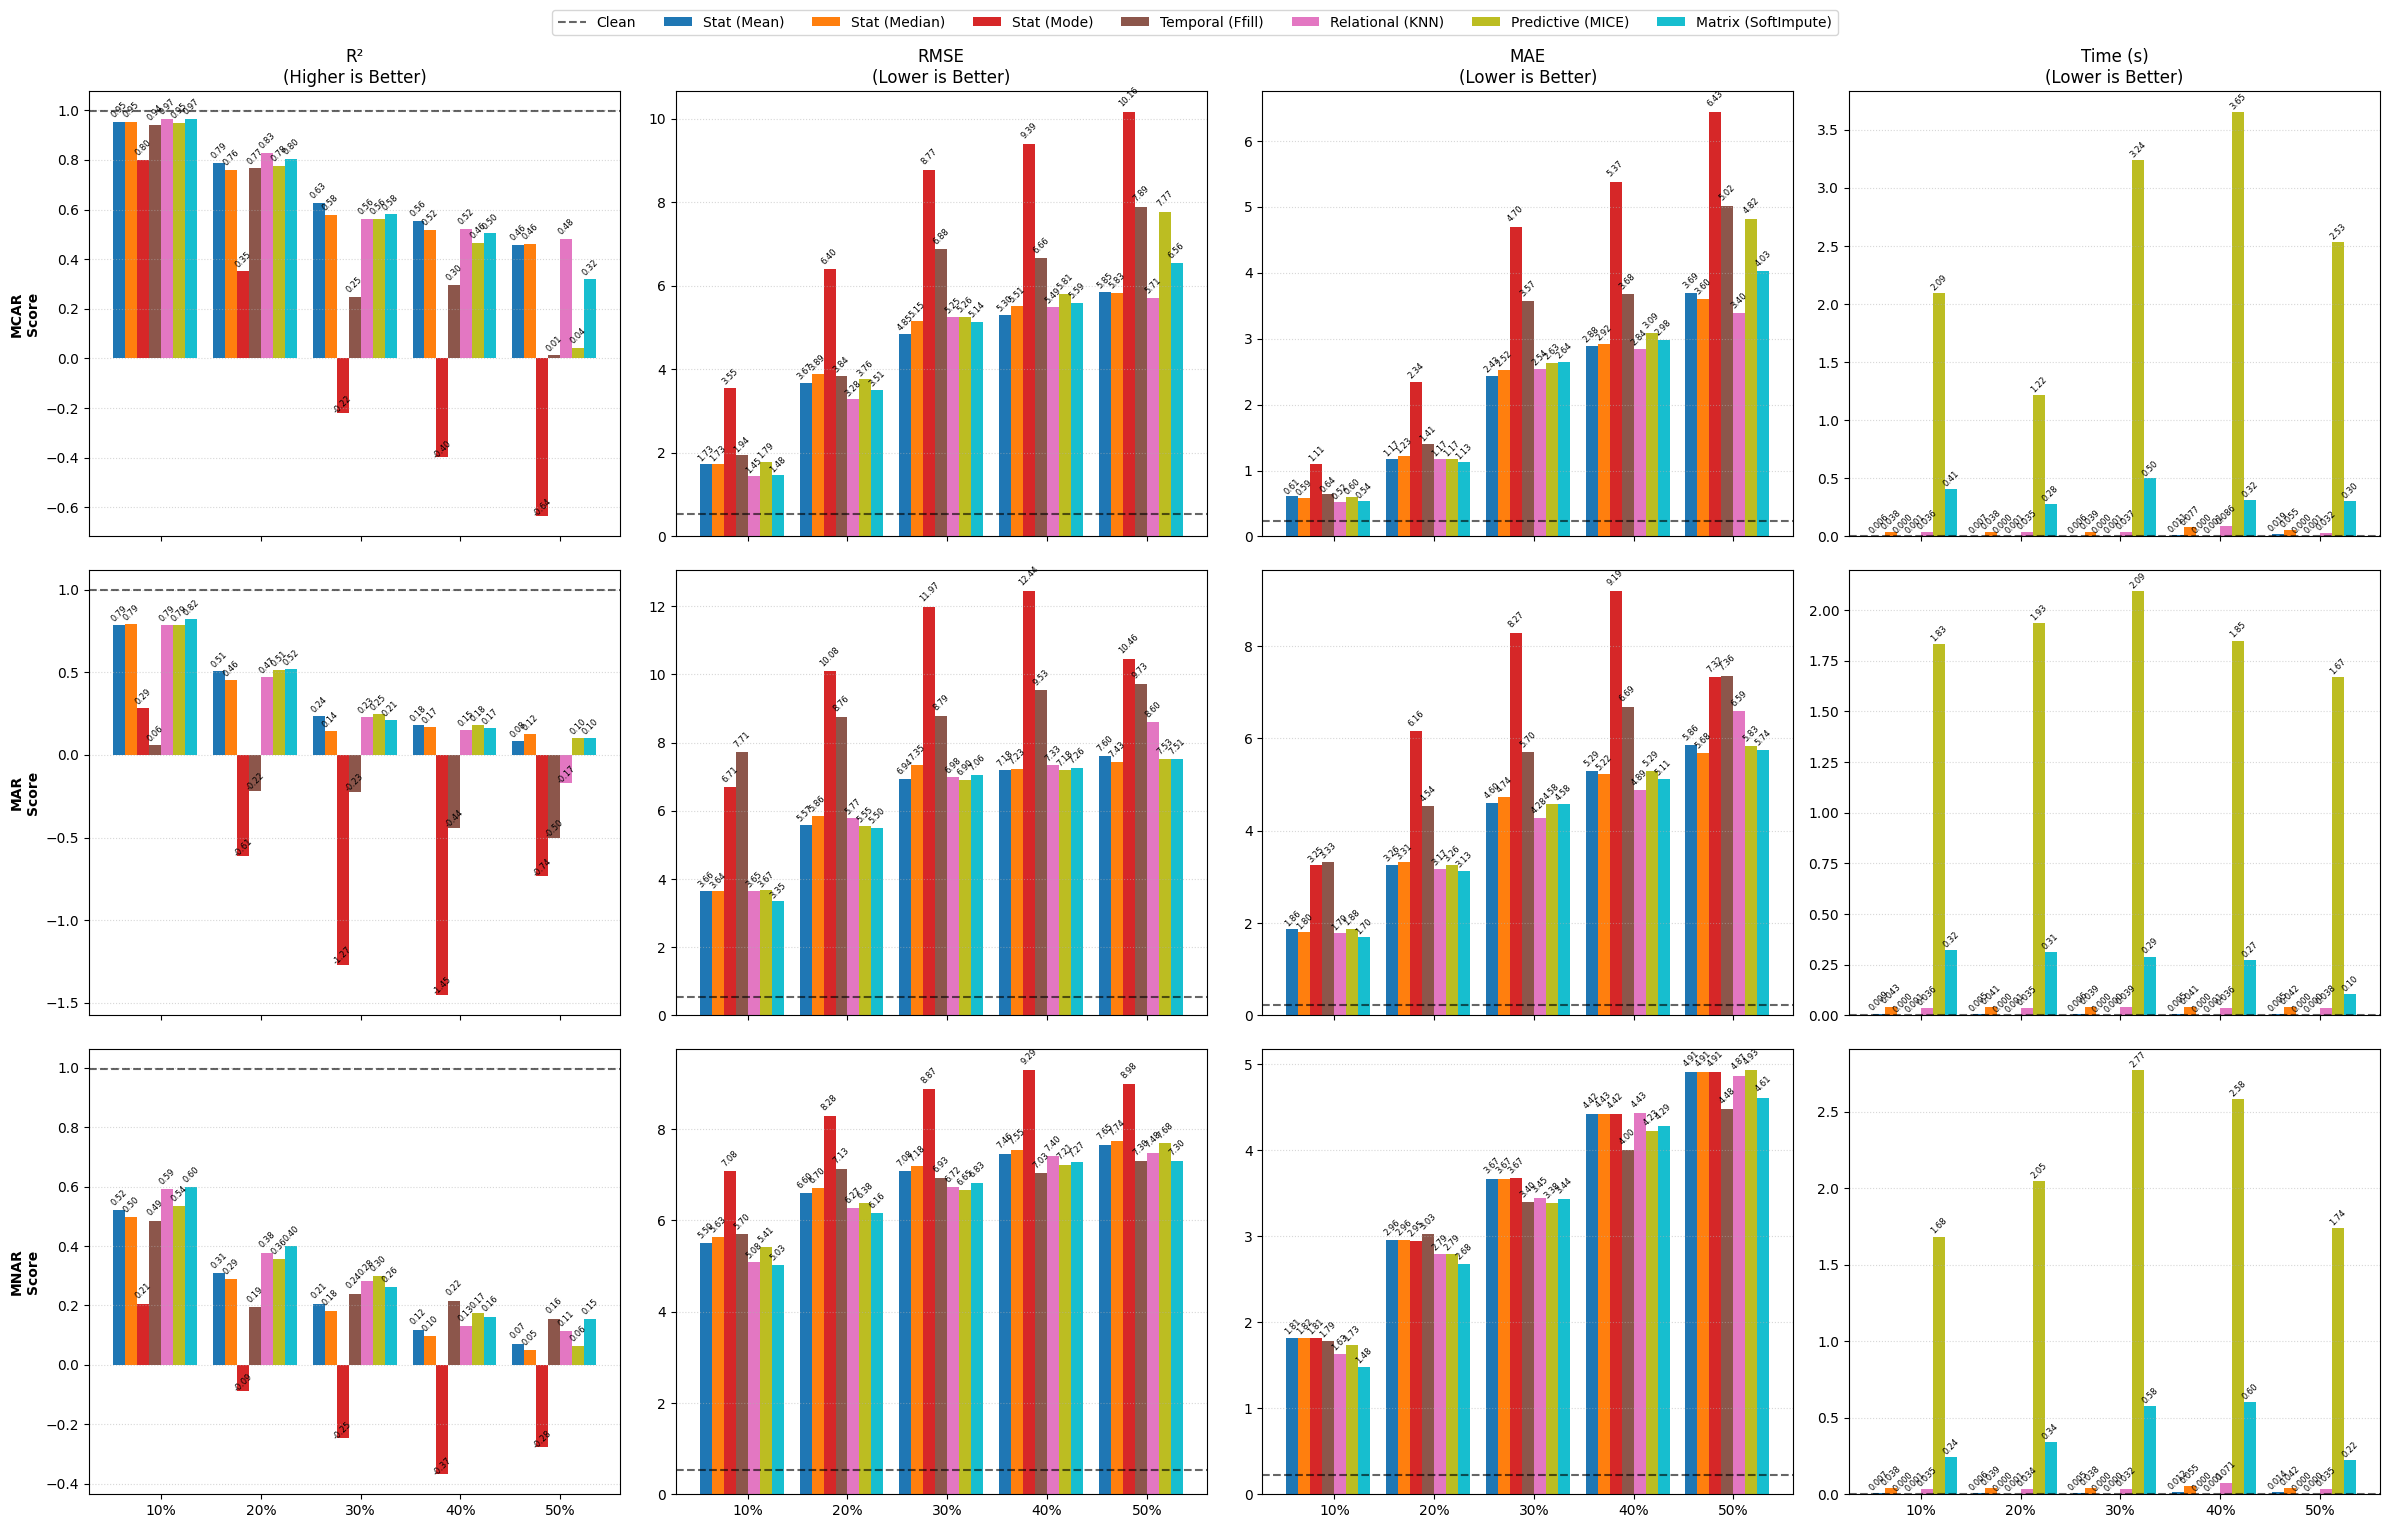

In [81]:
# Prepare data
plot_df = results_df[results_df['Strategy'] != 'Corrupted (Unrepaired)']
missing_types = plot_df['Type'].unique()
metrics = ['R²', 'RMSE', 'MAE', 'Time (s)']
strategies = [s for s in plot_df['Strategy'].unique() if s != 'Clean (Perfect Data)']

fig, axes = plt.subplots(len(missing_types), len(metrics), figsize=(24, 15), sharex=True)
colors = plt.cm.tab10(np.linspace(0, 1, len(strategies)))

for row, m_type in enumerate(missing_types):
    type_df = plot_df[plot_df['Type'] == m_type]
    rates = sorted(type_df['Rate'].unique())
    x = np.arange(len(rates))
    width = 0.12

    for col, metric in enumerate(metrics):
        ax = axes[row, col]

        # Plot Benchmark Line
        clean_val = plot_df[plot_df['Strategy'] == 'Clean (Perfect Data)'][metric].iloc[0]
        ax.axhline(y=clean_val, color='black', linestyle='--', alpha=0.6, label='Clean')

        # Plot Strategy Bars
        for i, strategy in enumerate(strategies):
            strat_data = type_df[type_df['Strategy'] == strategy]
            # Ensure rates match
            vals = [strat_data[strat_data['Rate'] == r][metric].values[0] for r in rates]
            bars = ax.bar(x + (i - len(strategies)/2) * width, vals, width, label=strategy, color=colors[i])

            # Add value labels on top of bars
            for bar, val in zip(bars, vals):
                # Adjust label positioning based on metric type
                if metric == 'R²':
                    label_y_offset = 0.01 if val > 0 else -0.01
                    format_str = '{:.2f}'
                elif metric == 'Time (s)':
                    label_y_offset = 0.005 # Small offset for time
                    format_str = '{:.3f}' if val < 0.1 else '{:.2f}'
                else: # RMSE, MAE
                    label_y_offset = 0.01 * bar.get_height() if bar.get_height() > 0.1 else 0.01
                    format_str = '{:.2f}'

                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + label_y_offset,
                        format_str.format(val),
                        ha='center', va='bottom', fontsize=6, rotation=45)

        if row == 0: ax.set_title(f"{metric}\n(Higher is Better)" if metric == 'R²' else f"{metric}\n(Lower is Better)")
        if col == 0: ax.set_ylabel(f"{m_type}\nScore", fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(rates)
        ax.grid(axis='y', linestyle=':', alpha=0.5)

# Single legend for the whole figure
handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=len(strategies)+1)
plt.tight_layout()
plt.show()

## **7. Detailed Leaderboards**

Here are the detailed leaderboards for RMSE, MAE, R² scores, and Execution Time across different missing rates.

In [80]:
def generate_leaderboard(df, metric, missing_type=None, ascending=True):
    """Refactored helper to handle multi-type missingness and pivot.
    Optionally filters by a specific missing_type.
    """

    if missing_type:
        df = df[df['Type'] == missing_type].copy()

    # Group by Strategy and Rate to get unique entries for pivoting
    df_grouped = df.groupby(['Strategy', 'Rate'])[metric].mean().reset_index()

    # Now pivot will work because each Strategy/Rate pair is unique
    pivot = df_grouped.pivot(index="Strategy", columns="Rate", values=metric)

    # Separate Benchmarks
    benchmarks = pivot[pivot.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])]
    strategies = pivot[~pivot.index.isin(['Clean (Perfect Data)', 'Corrupted (Unrepaired)'])].copy()

    # Loop-based Ranking (Robustly handles any number of % columns)
    rate_cols = [c for c in pivot.columns if '%' in str(c)]
    rank_cols = []
    for col in rate_cols:
        rank_name = f'Rank_{col}'
        strategies[rank_name] = strategies[col].rank(ascending=ascending, method='average')
        rank_cols.append(rank_name)

    # Aggregate Ranks
    strategies['Overall_Rank_Avg'] = strategies[rank_cols].mean(axis=1)
    strategies = strategies.sort_values('Overall_Rank_Avg')

    # Final Formatting
    display_df = strategies[rate_cols].copy()
    display_df.insert(0, 'Overall Rank', [f'#{i+1}' for i in range(len(display_df))])

    final_output = pd.concat([benchmarks.assign(**{'Overall Rank': 'N/A'}), display_df])
    return final_output, strategies['Overall_Rank_Avg']

# --- OVERALL LEADERBOARD GENERATION (Averaged across all missingness types) ---#

# --- 1. R² Score Leaderboard (Higher is Better) ---
print("\n" + "—"*60)
print("OVERALL LEADERBOARD: Strategy Utility (R² Score) by Missing Rate (Averaged across Types)")
print("—"*60)
pivot_r2_overall, strategies_r2_overall = generate_leaderboard(results_df, 'R²', ascending=False)
print(pivot_r2_overall)

# --- 2. RMSE Leaderboard (Lower is Better) ---
print("\n" + "—"*60)
print("OVERALL LEADERBOARD: RMSE (Lower is Better) by Missing Rate (Averaged across Types)")
print("—"*60)
pivot_rmse_overall, strategies_rmse_overall = generate_leaderboard(results_df, 'RMSE', ascending=True)
print(pivot_rmse_overall)

# --- 3. MAE Leaderboard (Lower is Better) ---
print("\n" + "—"*60)
print("OVERALL LEADERBOARD: MAE (Lower is Better) by Missing Rate (Averaged across Types)")
print("—"*60)
pivot_mae_overall, strategies_mae_overall = generate_leaderboard(results_df, 'MAE', ascending=True)
print(pivot_mae_overall)

# --- 4. Execution Time Leaderboard (Lower is Better) ---
print("\n" + "—"*60)
print("OVERALL LEADERBOARD: Execution Time (Lower is Better) by Missing Rate (Averaged across Types)")
print("—"*60)
pivot_time_overall, strategies_time_overall = generate_leaderboard(results_df, 'Time (s)', ascending=True)
print(pivot_time_overall)

# --- Overall Conclusive Leaderboard (Average Rank Across All Metrics) ---

# Combine the 'Overall_Rank_Avg' from each individual metric's strategies DataFrame.
combined_ranks_overall = pd.DataFrame({
    'R2_Rank_Avg': strategies_r2_overall,
    'RMSE_Rank_Avg': strategies_rmse_overall,
    'MAE_Rank_Avg': strategies_mae_overall,
    'Time_Rank_Avg': strategies_time_overall
})

# Calculate the ultimate overall average rank by averaging the average ranks from each metric.
combined_ranks_overall['Overall_Avg_Rank'] = combined_ranks_overall.mean(axis=1)

# Sort by the overall average rank to get the conclusive leaderboard (lower average rank is better)
conclusive_leaderboard_overall = combined_ranks_overall.sort_values(by='Overall_Avg_Rank', ascending=True)

# Insert a formatted 'Overall Conclusive Rank' column for display
conclusive_leaderboard_overall.insert(0, 'Overall Conclusive Rank', [f'#{i+1}' for i in range(len(conclusive_leaderboard_overall))])

print("\n" + "—"*60)
print("ULTIMATE OVERALL CONCLUSIVE LEADERBOARD (Average Rank Across All Metrics & Missingness Types)")
print("—"*60)
print(conclusive_leaderboard_overall)


# --- DETAILED LEADERBOARDS PER MISSINGNESS TYPE ---#
missing_types = results_df['Type'].unique()

for m_type in missing_types:
    print(f"\n\n{'='*70}\nDETAILED LEADERBOARDS FOR MISSINGNESS TYPE: {m_type}\n{'='*70}")

    # --- 1. R² Score Leaderboard (Higher is Better) for specific type ---
    print("\n" + "—"*60)
    print(f"LEADERBOARD: Strategy Utility (R² Score) by Missing Rate ({m_type})")
    print("—"*60)
    pivot_r2_ranked, _ = generate_leaderboard(results_df, 'R²', missing_type=m_type, ascending=False)
    print(pivot_r2_ranked)

    # --- 2. RMSE Leaderboard (Lower is Better) for specific type ---
    print("\n" + "—"*60)
    print(f"LEADERBOARD: RMSE (Lower is Better) by Missing Rate ({m_type})")
    print("—"*60)
    pivot_rmse_ranked, _ = generate_leaderboard(results_df, 'RMSE', missing_type=m_type, ascending=True)
    print(pivot_rmse_ranked)

    # --- 3. MAE Leaderboard (Lower is Better) for specific type ---
    print("\n" + "—"*60)
    print(f"LEADERBOARD: MAE (Lower is Better) by Missing Rate ({m_type})")
    print("—"*60)
    pivot_mae_ranked, _ = generate_leaderboard(results_df, 'MAE', missing_type=m_type, ascending=True)
    print(pivot_mae_ranked)

    # --- 4. Execution Time Leaderboard (Lower is Better) for specific type ---
    print("\n" + "—"*60)
    print(f"LEADERBOARD: Execution Time (Lower is Better) by Missing Rate ({m_type})")
    print("—"*60)
    pivot_time_ranked, _ = generate_leaderboard(results_df, 'Time (s)', missing_type=m_type, ascending=True)
    print(pivot_time_ranked)


————————————————————————————————————————————————————————————
OVERALL LEADERBOARD: Strategy Utility (R² Score) by Missing Rate (Averaged across Types)
————————————————————————————————————————————————————————————
Rate                         10%        20%        30%        40%        50%  \
Strategy                                                                       
Clean (Perfect Data)    0.995607   0.995607   0.995607   0.995607   0.995607   
Corrupted (Unrepaired) -8.956518 -17.986012 -27.756010 -33.238323 -38.082774   
Matrix (SoftImpute)     0.795639   0.574322   0.350676   0.277105   0.192592   
Relational (KNN)        0.782077   0.559248   0.357940   0.267093   0.141215   
Stat (Mean)             0.753530   0.535003   0.356299   0.284889   0.204064   
Predictive (MICE)       0.756936   0.547338   0.368027   0.273648   0.068635   
Stat (Median)           0.746833   0.501065   0.301388   0.262043   0.211329   
Temporal (Ffill)        0.494307   0.247833   0.087827   0.024683  -

### **8. Visualizing the Guess vs. The Truth**
This cell provides a direct visual comparison of actual target values against the predictions made after imputation by a select few strategies. It helps to intuitively understand how well each strategy reconstructs the underlying signal.

1.  **Ground Truth Plot**: The actual `y_test` values (first 60 samples) are plotted as a thick black line, representing the 'ACTUAL TRUTH'.
2.  **Candidate Strategies**: A list `candidates` is chosen for visual comparison, focusing on a few representative imputation methods.
3.  **Prediction Plots**: For each candidate strategy, the first 60 predicted values from the `prediction_samples` dictionary (which contains predictions at a 20% failure rate) are plotted as dashed lines. This allows for a direct visual assessment of how closely the imputed predictions track the true values.

In [ ]:
plt.figure(figsize=(15, 7))

#WILL FIX THIS LATER

# Plot the Ground Truth
plt.plot(y_test.values[:60], label='ACTUAL TRUTH', color='black', linewidth=4, alpha=0.7)

# Select key candidates for the visual battle
candidates = ["Stat (Median)", "Relational (KNN)", "Matrix (SoftImpute)", "Temporal (Ffill)"]

for c in candidates:
    plt.plot(prediction_samples[c][:60], label=f'Repair: {c}', linestyle='--', alpha=0.9)

plt.title("The 'Hallucination' Test: Comparing Repair Accuracy (20% Failure Rate)", fontsize=14)
plt.ylabel("Fridge Power (Watts)")
plt.xlabel("Timeline (Sample Points)")
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, alpha=0.2)
plt.show()